Euler's Method

In [1]:
import numpy as np
import matplotlib.pyplot as plt

y_exact(15) = 0.2723749469966798

Step size = 0.01
average error = 0.3690162712706906
y_approx(15) = 0.2324896386610591
local error = 0.039885308335620706

Step size = 0.06
average error = 1.3922379560843439
y_approx(15) = 0.1042254523988114
local error = 0.1681494945978684

Step size = 0.11
average error = 1.7944599962359518
y_approx(15) = 0.04286503543849603
local error = 0.2295099115581838

Step size = 0.16
average error = 1.9819611058474118
y_approx(15) = 0.019054816287470553
local error = 0.2533201307092092

Step size = 0.21
average error = 2.0830076538457942
y_approx(15) = 0.006317489411607971
local error = 0.2660574575850718

Step size = 0.26
average error = 2.143578206137583
y_approx(15) = 0.0020072941155582155
local error = 0.2703676528811216

Step size = 0.31
average error = 2.1829461209888454
y_approx(15) = 0.0005406650667227439
local error = 0.27183428192995707

Step size = 0.36
average error = 2.2093021400179182
y_approx(15) = 0.00013962454363313455
local error = 0.2722353

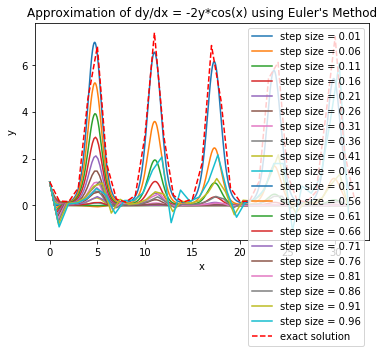

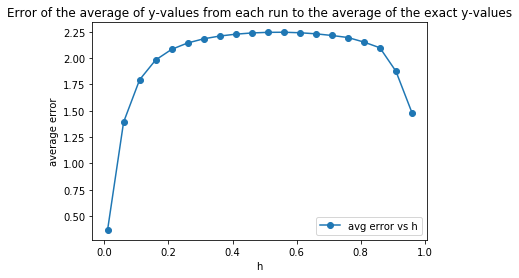

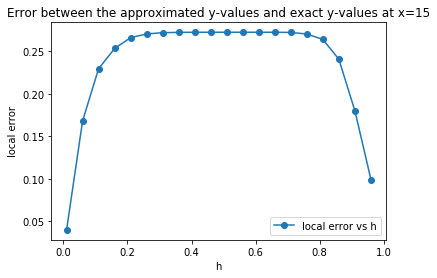

In [2]:
# Define parameters
h = np.arange(0.01, 1.01, 0.05)  # step size
x_start, x_end = 0, 10*np.pi

# Function representing dy/dx
def f(x, y):
    return -2 * y * np.cos(x)

def exactSolution(x):
    return np.exp(-2 * np.sin(x))

# Calculate y when x = 15 (following HW7 instructions)
y_exactVal = exactSolution(15)
print("y_exact(15) =", y_exactVal)

averageError = []
localError = []

for j in range (0, len(h)):
    print("\nStep size =", f"{h[j]:.2f}")
    
    num_steps = int((x_end - x_start) / h[j])
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    
    # Initial condition
    y_values[0] = 1  # y(0) = 1

    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h[j] * f(x_values[i], y_values[i])
    
    # Calculate exact solution
    y_exact = exactSolution(x_values)
    
    # Calculate error
    y_average = np.mean(y_values)
    y_exactAvg = np.mean(y_exact)
    avgError = np.abs(y_average - y_exactAvg)
    
    # Find the y value where x approximately equals 15
    y_approxVal = 0
    for i in range(len(x_values)):
        if (x_values[i]>15):
            if (np.abs(x_values[i-1]-15) < np.abs(x_values[i]-15)):
                y_approxVal = y_values[i-1]
            else:
                y_approxVal = y_values[i]
            break
            
    pointError = np.abs(y_approxVal - y_exactVal)

    print("average error =", avgError)
    print("y_approx(15) =", y_approxVal)
    print("local error =", pointError)
    
    # Create a list of average errors and global errors for plotting
    averageError.append(avgError)
    localError.append(pointError)
    
    # Plot the results
    plt.plot(x_values, y_values, label=f"step size = {h[j]:.2f}")
    
    
x = np.arange(0, 10*np.pi + 1)
    
# Plot the results
plt.plot(x, exactSolution(x), 'r--', label='exact solution')
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y*cos(x) using Euler's Method")
plt.legend()
plt.show()

plt.plot(h, averageError, 'o-', label='avg error vs h')
plt.xlabel('h')
plt.ylabel('average error')
plt.legend()
plt.title("Error of the average of y-values from each run to the average of the exact y-values")
plt.show()

plt.plot(h, localError, 'o-', label='local error vs h')
plt.xlabel('h')
plt.ylabel('local error')
plt.legend()
plt.title("Error between the approximated y-values and exact y-values at x=15")
plt.show()

As the step size increases, the average error value and local error increase because each run produces a result that is less accurate to the exact solution of the differential equation. Furthermore, the plots of each approximation with a smaller step size are more comparable to the plot of the exact solution. As step size increases, the graph becomes unstable because it can no longer capture the oscillations of the trigometric functions accurately; accuracy of Euler's Method decreases as step size inreases.

Yes, we can do a stability analysis on -2y* cos(x).

In the example for f(x, y) = -2y, we used dy/dt = λy to find that λ = -2. Therefore, for this function, λ = -2cos(x). This λ value is not constant like the previous example, and instead relies on varying values of x:

    For cos(x) < 0, λ > 0 therefore the function is unstable. (Explanation: accoording to lectures slides 17b., Euler's Method
      is not reliable for exponential growth.)
    For cos(x) > 0, λ < 0 therefore the function is stable.
    For cos(x) = 0, λ = 0

Stability condition:

    |1+hλ| < 1
    |1+h(-2cos(x))| < 1
        --> -1 < 1+h(-2cos(x)) < 1
            --> -2 < h(-2cos*x))
            --> h(-2cos(x) < 0
                --> 0 < h < 1/cos(x)
            cos(x) ranges from (0, 1) for x values between (0, 2pi)
            therefore h must be between (0, 1)